# Algorithm Benchmarking & Analysis
This notebook runs the algorithms, processes the JSON results, and generates visualizations and LaTeX tables.

In [1]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from algorithm.branch_and_bound import BranchAndBound
from algorithm.cp import CP
from algorithm.mip import MIP
from algorithm.heuristic import greedy, LocalSearch
from algorithm.aco import ACO
from algorithm.alns import ALNS
from benchmark import my_input_parser, run_benchmark

In [2]:
# Global Plotting Settings
sns.set_theme()
sns.set_context("paper", font_scale=1.2)
sns.set_style("ticks")
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

# Execution Order
algo_list = [BranchAndBound, CP, MIP, greedy, LocalSearch, ACO, ALNS]

## 1. Run Benchmarks

In [3]:
TEST_PATH = "hustack_test_cases"

In [4]:
#un_benchmark(TEST_PATH, my_input_parser, BranchAndBound, time_limit=300)

In [5]:
#run_benchmark(TEST_PATH, my_input_parser, CP, time_limit=300)

In [6]:
#run_benchmark(TEST_PATH, my_input_parser, MIP, time_limit=300)

In [7]:
#un_benchmark(TEST_PATH, my_input_parser, greedy, time_limit=300)

In [8]:
#run_benchmark(TEST_PATH, my_input_parser, LocalSearch, time_limit=300)

In [9]:
#run_benchmark(TEST_PATH, my_input_parser, ACO, time_limit=300)

In [10]:
#run_benchmark(TEST_PATH, my_input_parser, ALNS, time_limit=300)

## 2. Compile DataFrames

In [11]:
time_df = pd.DataFrame()
cost_df = pd.DataFrame()

for algo in algo_list[::-1]:
    name = algo.__name__

    with open(f"results/{name}_results.json", "r") as f:
        results = json.load(f)
    N = [result["N"] for result in results]
    runtime = [result["runtime"] for result in results]
    cost = [result["cost"] for result in results]

    time_df[name] = pd.Series(runtime, index=N)
    cost_df[name] = pd.Series(cost, index=N)

# Rename columns for presentation
rename_dict = {'greedy': 'Greedy', 'LocalSearch': 'Local Search', 'BranchAndBound': 'Branch and Bound'}
time_df.rename(columns=rename_dict, inplace=True)
cost_df.rename(columns=rename_dict, inplace=True)

#Clean data: Convert string markers like 'TLE' and 'OOM' to NaN so Matplotlib can plot the remaining numbers
time_df = time_df.apply(pd.to_numeric, errors='coerce')
cost_df = cost_df.apply(pd.to_numeric, errors='coerce')

time_df = time_df[time_df.columns[::-1]]  # Reverse column order for plotting
cost_df = cost_df[cost_df.columns[::-1]]  # Reverse column order for plotting

time_df = time_df[time_df.index <= 1000]
cost_df = cost_df[cost_df.index <= 1000]

In [12]:
time_df = np.trunc(time_df * 100) / 100  # Truncate to two decimal places
cost_df = np.trunc(cost_df * 100) / 100  # Truncate to two decimal places

## 3. LaTeX Table Export

In [13]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [14]:
# ---------------------------------------------------------
# CUSTOM LATEX GENERATOR (Caption at the Bottom)
# ---------------------------------------------------------
num_algos = len(time_df.columns)
algos = list(time_df.columns)

total_cols = 1 + (2 * num_algos)

latex_lines = []
latex_lines.append(r"\begin{table}[h!]")
latex_lines.append(r"\centering")
# REMOVED CAPTION AND LABEL FROM HERE

# Auto-scale to fit the page width
latex_lines.append(r"\resizebox{\textwidth}{!}{")
# Define the strict grid format
latex_lines.append(r"\begin{tabular}{|c|" + "c|c|" * num_algos + "}")
latex_lines.append(r"\hline")

# --- Header Row 1: Vertically Centered Input N & Algorithm Names ---
row1 = [r"\multirow{2}{*}{Input $N$}"]
for algo in algos:
    row1.append(rf"\multicolumn{{2}}{{c|}}{{{algo}}}")
latex_lines.append(" & ".join(row1) + rf" \\ \cline{{2-{total_cols}}}")

# --- Header Row 2: Cost and Time Sub-headers ---
row2 = [""] 
for _ in algos:
    row2.append(r"\makebox[1.4cm][c]{Cost}") 
    row2.append(r"\makebox[1.4cm][c]{Time(s)}")
latex_lines.append(" & ".join(row2) + r" \\ \hline")

# --- Data Rows ---
for N in time_df.index:
    row_data = [str(N)]
    for algo in algos:
        cost_val = cost_df.loc[N, algo]
        time_val = time_df.loc[N, algo]

        cost_str = f"{int(cost_val)}" if pd.notna(cost_val) else "TLE"
        time_str = f"{time_val:.2f}" if pd.notna(time_val) else "TLE" 

        row_data.append(cost_str)
        row_data.append(time_str)
    
    latex_lines.append(" & ".join(row_data) + r" \\") 

# --- Bottom Border ---
latex_lines.append(r"\hline")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"}") # Closes the resizebox

# ADDED CAPTION AND LABEL HERE (Below the table)
latex_lines.append(r"\caption{Combined Cost and Runtime Comparison of Algorithms}")
latex_lines.append(r"\label{tab:combined_results}")

latex_lines.append(r"\end{table}")

# Stack the long algorithm names to prevent stretching
latex_str = "\n".join(latex_lines)
latex_str = latex_str.replace("Branch and Bound", "\\shortstack{Branch \\& \\\\ Bound}")
latex_str = latex_str.replace("Local Search", "\\shortstack{Local \\\\ Search}")

# Print the final LaTeX code
print("%%% COMBINED RESULTS TABLE %%%")
print(latex_str)

%%% COMBINED RESULTS TABLE %%%
\begin{table}[h!]
\centering
\resizebox{\textwidth}{!}{
\begin{tabular}{|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|}
\hline
\multirow{2}{*}{Input $N$} & \multicolumn{2}{c|}{\shortstack{Branch \& \\ Bound}} & \multicolumn{2}{c|}{CP} & \multicolumn{2}{c|}{MIP} & \multicolumn{2}{c|}{Greedy} & \multicolumn{2}{c|}{\shortstack{Local \\ Search}} & \multicolumn{2}{c|}{ACO} & \multicolumn{2}{c|}{ALNS} \\ \cline{2-15}
 & \makebox[1.4cm][c]{Cost} & \makebox[1.4cm][c]{Time(s)} & \makebox[1.4cm][c]{Cost} & \makebox[1.4cm][c]{Time(s)} & \makebox[1.4cm][c]{Cost} & \makebox[1.4cm][c]{Time(s)} & \makebox[1.4cm][c]{Cost} & \makebox[1.4cm][c]{Time(s)} & \makebox[1.4cm][c]{Cost} & \makebox[1.4cm][c]{Time(s)} & \makebox[1.4cm][c]{Cost} & \makebox[1.4cm][c]{Time(s)} & \makebox[1.4cm][c]{Cost} & \makebox[1.4cm][c]{Time(s)} \\ \hline
5 & 380 & 0.37 & 380 & 0.41 & 380 & 0.47 & 380 & 0.38 & 380 & 0.29 & 380 & 0.31 & 380 & 0.46 \\
10 & 620 & 0.28 & 620 & 0.28 & 620 & 0.30 & 620 & 0.26 & 620 & 

## 4. Visualizations

In [15]:
my_colors = {
    'Branch and Bound': "#64614f",
    'CP': '#4363d8',            
    'MIP': "#9db0f3",           
    'Greedy': '#911eb4',        
    'Local Search': "#247878",   
    'ACO': "#77aa82",           
    'ALNS': "#5387bf"         
}

my_styles = {
    'Branch and Bound': 'x-',
    'CP': 'o--',
    'MIP': '^-.',
    'Greedy': 'D:',
    'Local Search': 's-',
    'ACO': 'v--',
    'ALNS': '*-.',
}

time_cols = time_df.columns
time_colors = [my_colors[c] for c in time_cols if c in my_colors]
time_styles = [my_styles[c] for c in time_cols if c in my_styles]

cost_cols = cost_df.columns
cost_colors = [my_colors[c] for c in cost_cols if c in my_colors]
cost_styles = [my_styles[c] for c in cost_cols if c in my_styles]

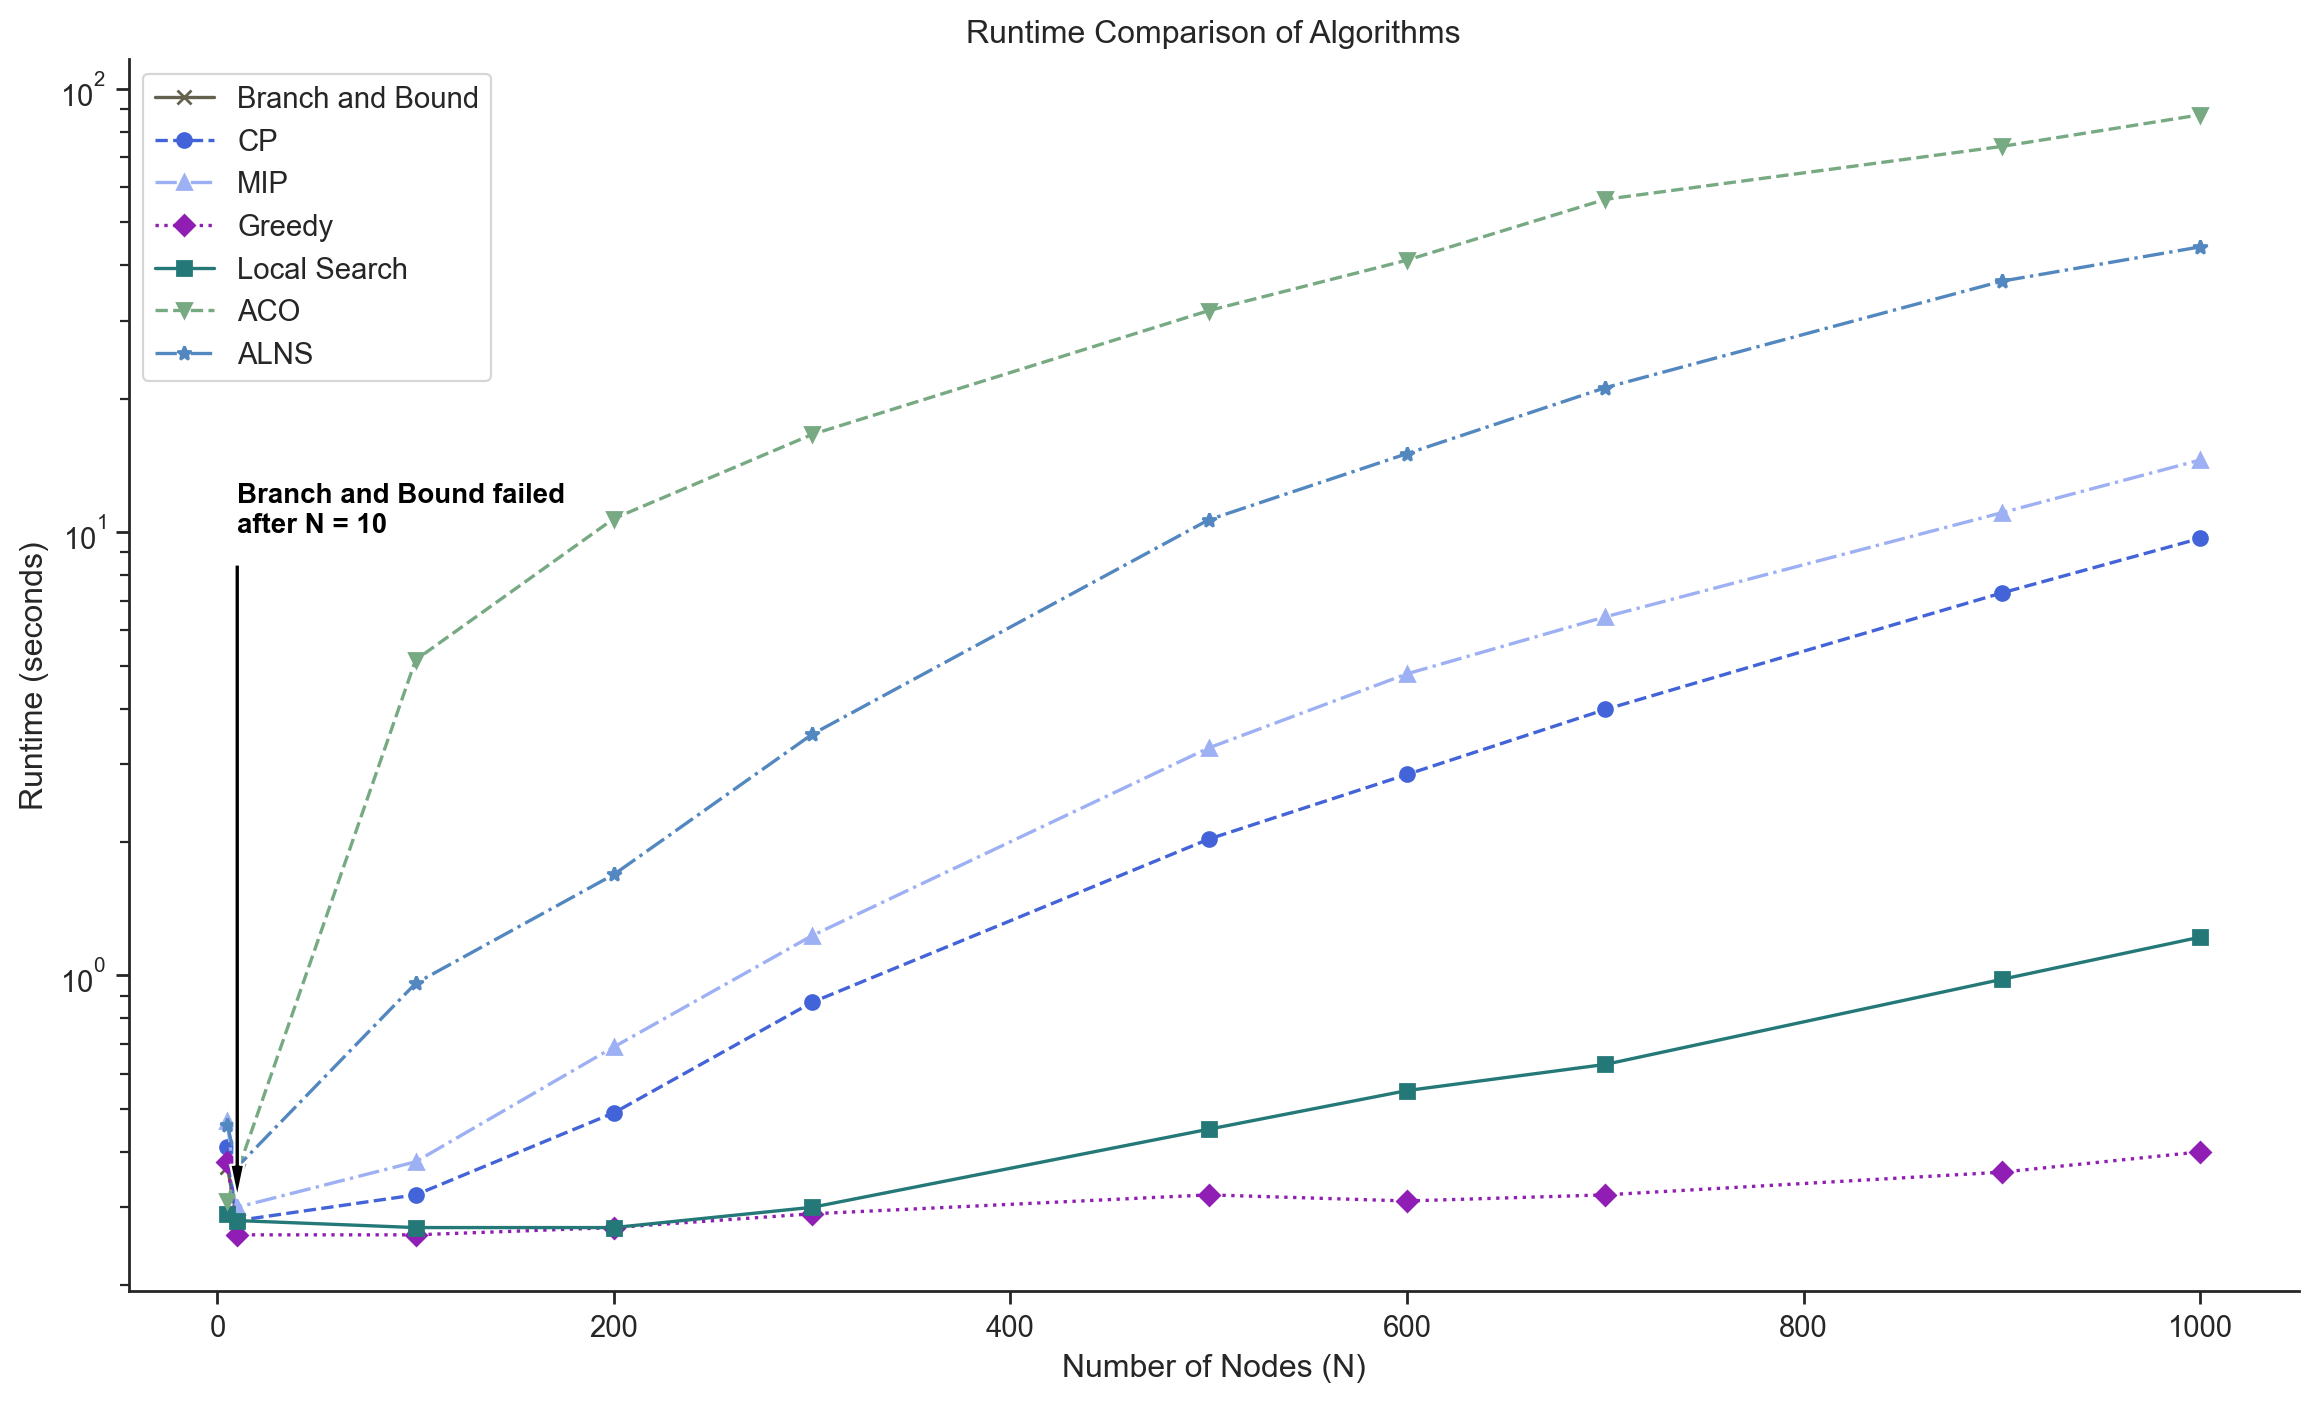

In [32]:
# 1. Runtime Comparison Graph
ax1 = time_df.plot(
    figsize=(14, 8),
    title="Runtime Comparison of Algorithms", 
    xlabel="Number of Nodes (N)", 
    ylabel="Runtime (seconds)", 
    style=time_styles, 
    markersize=5, 
    logy=True, 
    color=time_colors, 
    legend=True
)

ax1.annotate(
    'Branch and Bound failed\nafter N = 10',
    xy = (10, 0.282990),
    xytext = (10, 10),
    arrowprops=dict(facecolor='black', shrink=0.03, width=2, headwidth=5), 
    fontsize=10, color='black', weight='bold')

sns.despine()
plt.savefig("runtime_comparison.svg", format='svg', bbox_inches='tight')
plt.show()

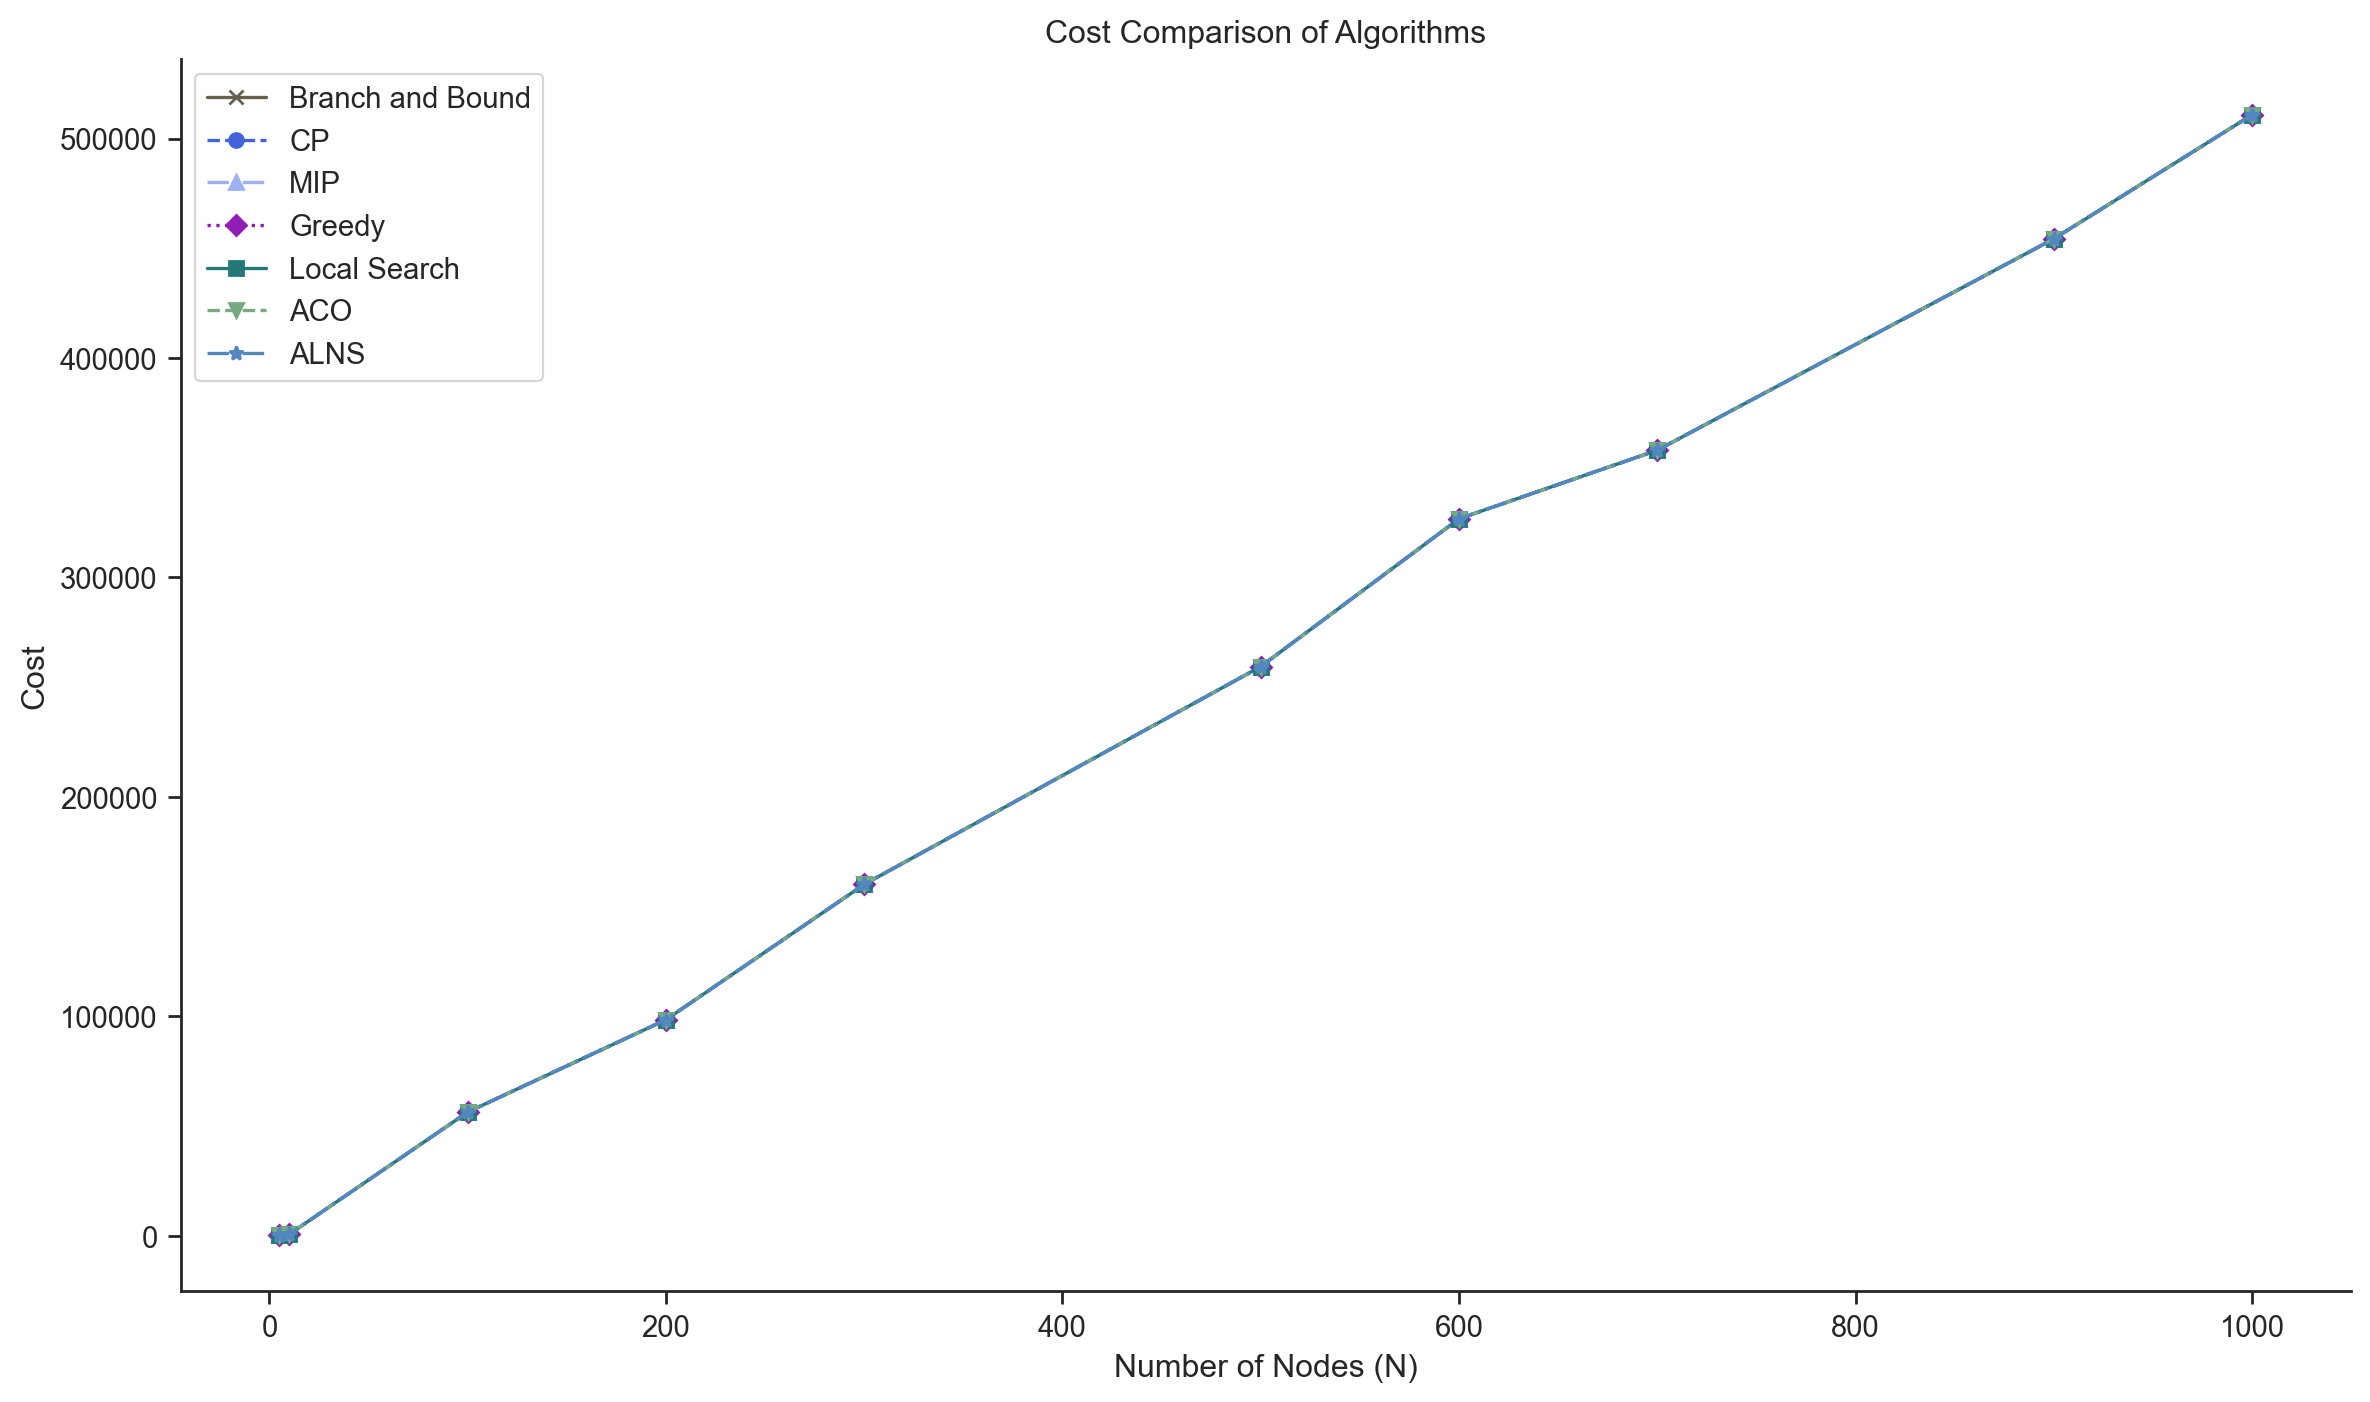

In [17]:
# 2. Raw Cost Comparison Graph
ax2 = cost_df.plot(
    figsize=(14, 8),
    title="Cost Comparison of Algorithms", 
    xlabel="Number of Nodes (N)", 
    ylabel="Cost", 
    style=cost_styles, 
    markersize=5,  
    color=cost_colors, 
    legend=True
)
sns.despine()
plt.savefig("cost_comparison.svg", format='svg', bbox_inches='tight')
plt.show()

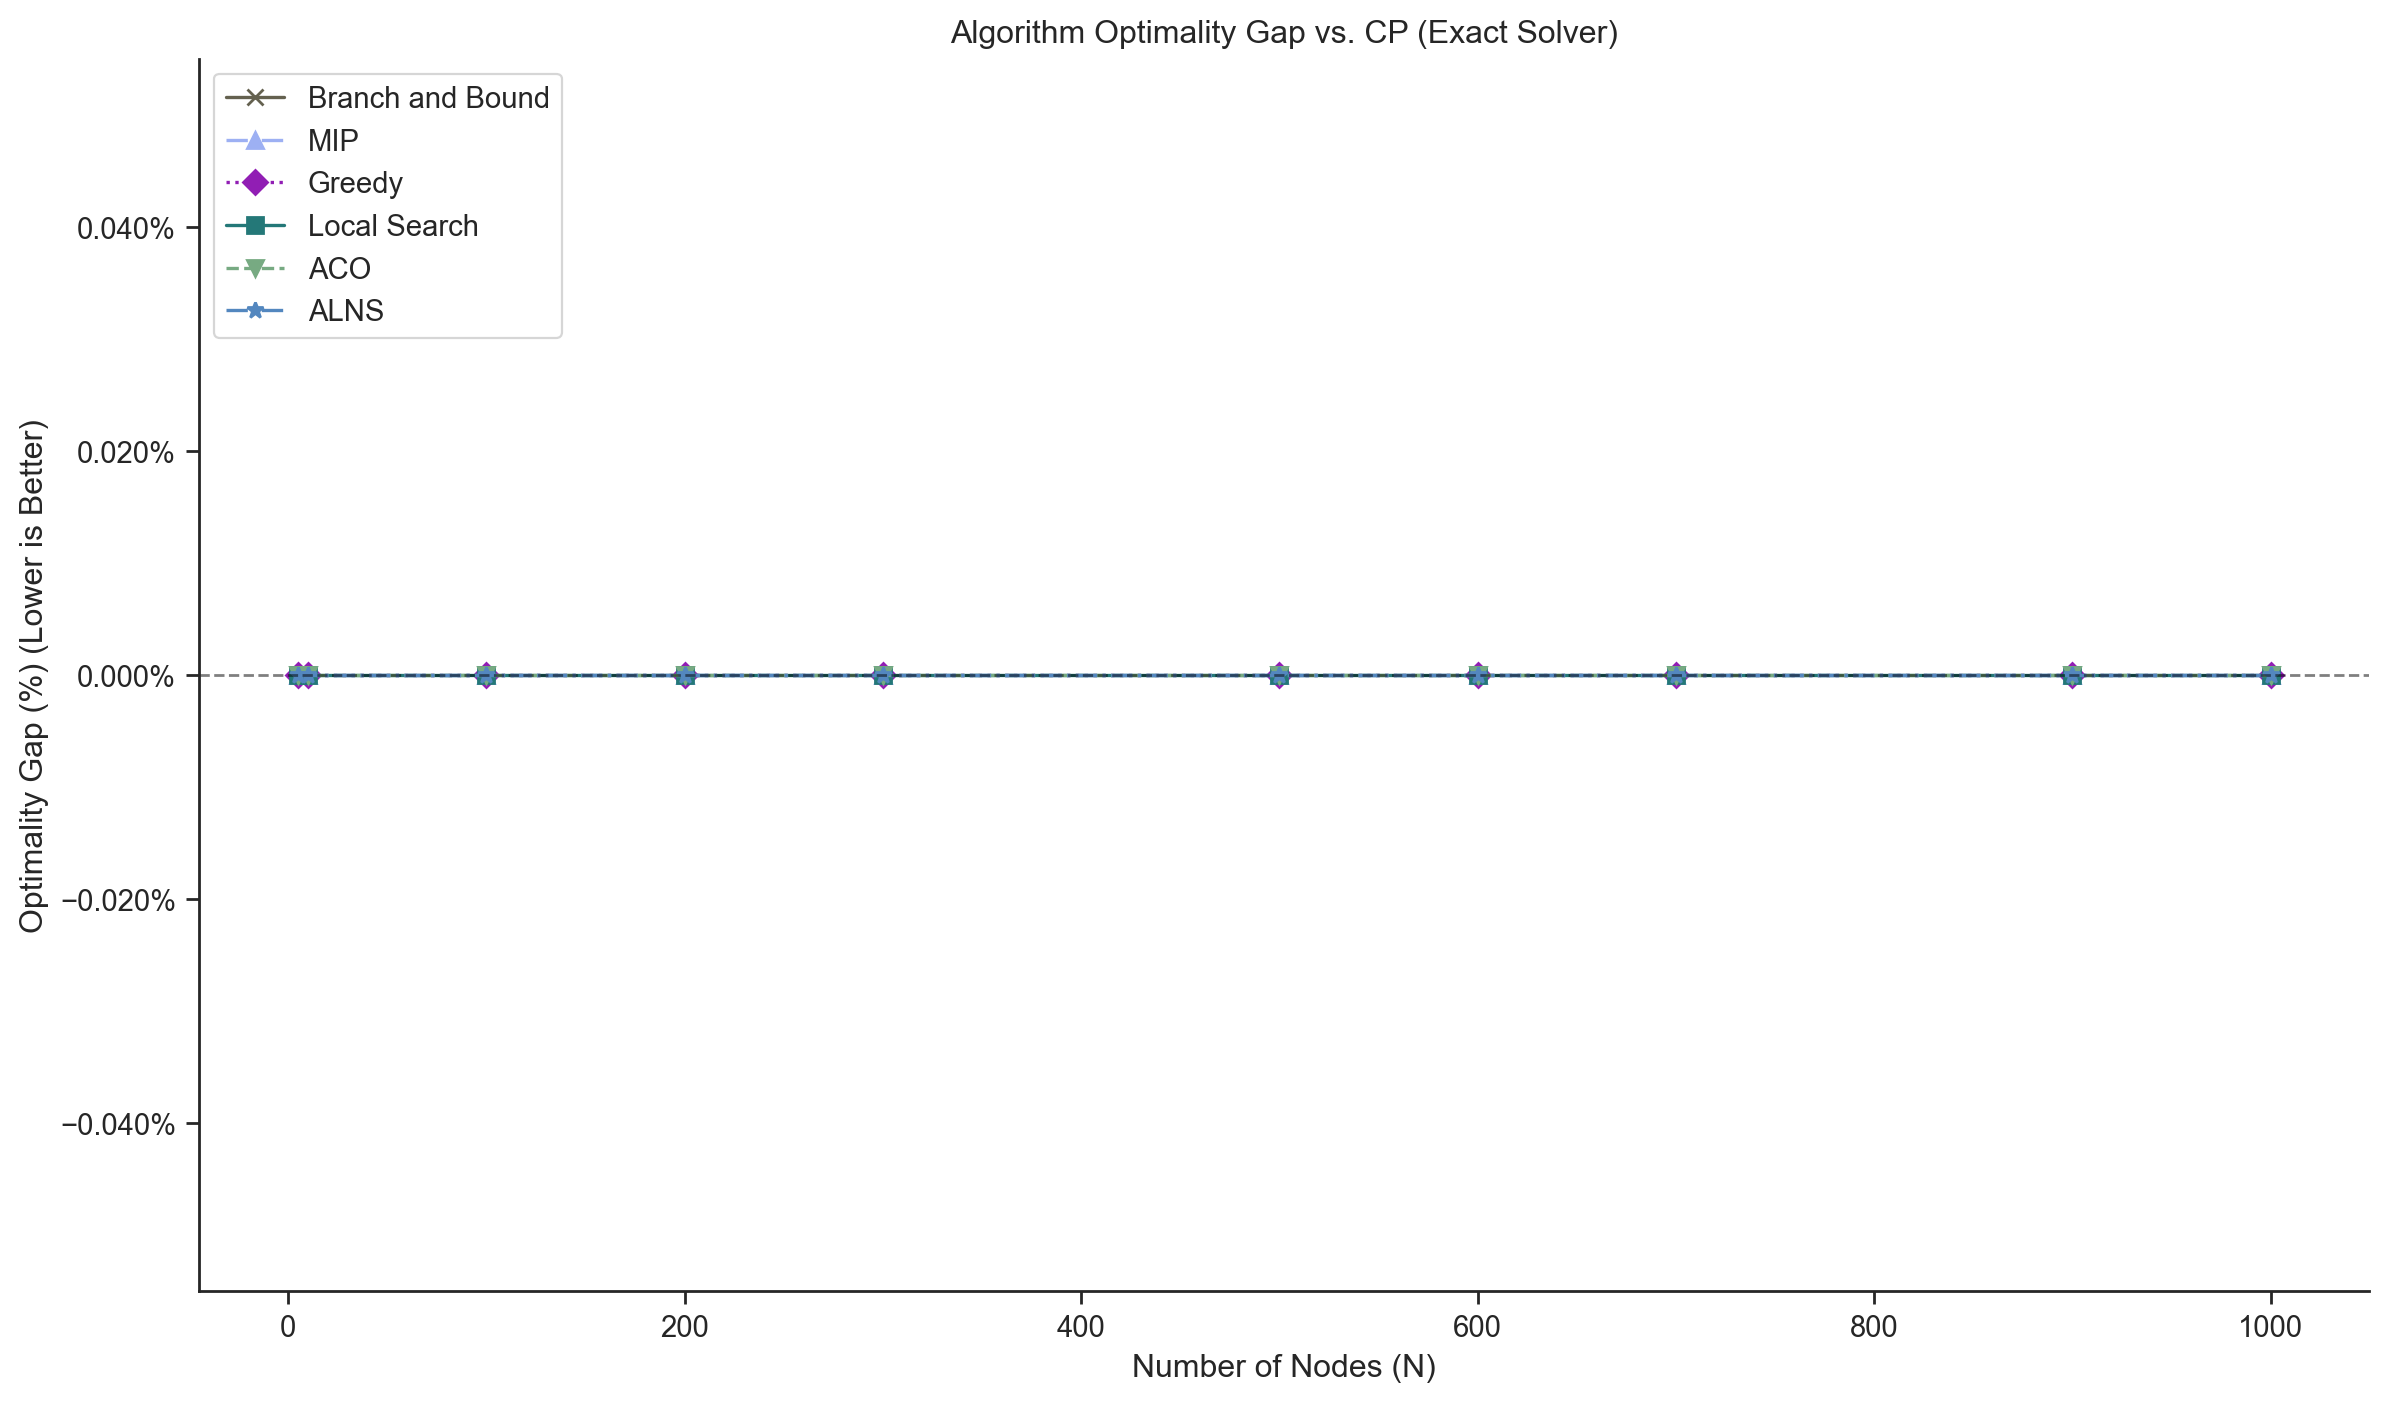

In [18]:
diff_df = pd.DataFrame(index=cost_df.index)

for col in cost_df.columns:
    if col != 'CP':
        # Calculate percentage difference from Greedy
        diff_df[col] = ((cost_df[col] - cost_df['CP']) / cost_df['CP']) * 100

diff_colors = [my_colors[c] for c in diff_df.columns if c in my_colors]
diff_styles = [my_styles[c] for c in diff_df.columns if c in my_styles]

ax3 = diff_df.plot(
    figsize=(14, 8),
    title="Algorithm Optimality Gap vs. CP (Exact Solver)", 
    xlabel="Number of Nodes (N)",
    ylabel="Optimality Gap (%) (Lower is Better)",
    style=diff_styles,
    markersize=6,
    color=diff_colors,
    legend=True
)
ax3.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.legend(loc="upper left") 
sns.despine()
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5) 
plt.savefig("cost_gap_comparison.svg", format='svg', bbox_inches='tight')
plt.show()